Name: sinya kumari
CMS ID: 023-24-0227
Section-G

# Part 1 — Problem Definition & Dataset Verification

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("Downloads/clean_churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows with missing values
df = df.dropna()

# Convert target variable Churn to 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop customer identifier
df = df.drop(columns=["customerID"])

# One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())
print(y.head())

X shape: (7043, 30)
y shape: (7043,)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False       

 Task 4 — Why does scaling matter?

Feature scaling is useful for KNN because it uses distances between data points, and features with bigger values can have more impact on the result. Logistic Regression also works better with scaled features because it helps the model train more smoothly. However, scaling is not needed for Decision Trees and Random Forests because their decisions are based on feature splits, not distances.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (5634, 30)
Testing set shape: (1409, 30)


Why fit the scaler only on training data?
The scaler finds the mean and standard deviation from the data. If we fit it on both training and testing data, the test data would influence the training process. This can cause data leakage and make the model’s performance look better than it actually is.
.

In [6]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model using scaled training data
logistic_model.fit(X_train_scaled, y_train)

# Generate predictions on scaled test data
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:10])

Predictions:
[0 1 0 0 0 1 0 0 0 0]


Task 7 — Accuracy, Precision, Recall, F1-Score & Confusion Matrix

Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1-Score : 0.6091954022988506

Confusion Matrix:
[[925 110]
 [162 212]]


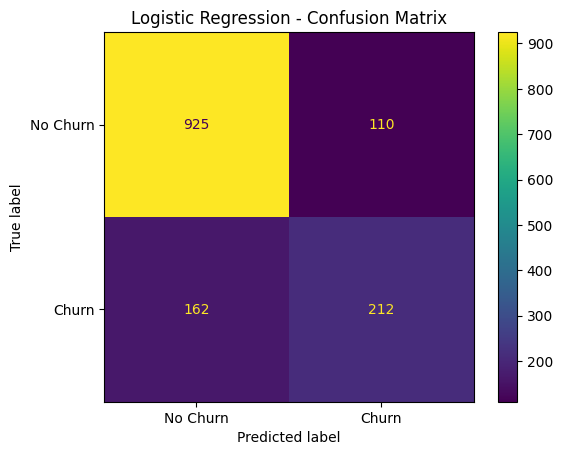

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [11]:
# Get probabilities for first 5 test customers
probabilities = logistic_model.predict_proba(X_test_scaled[:5])

 
for i, prob in enumerate(probabilities):
    print(
        f"Customer {i+1}: "
        f"No Churn = {prob[0]:.3f}, "
        f"Churn = {prob[1]:.3f}"
    )

Customer 1: No Churn = 0.955, Churn = 0.045
Customer 2: No Churn = 0.317, Churn = 0.683
Customer 3: No Churn = 0.943, Churn = 0.057
Customer 4: No Churn = 0.592, Churn = 0.408
Customer 5: No Churn = 0.978, Churn = 0.022


`predict_proba()` shows the probability of each class. The first value is for No Churn, while the second is for Churn. The `predict()` function chooses the class with the higher probability, so if the Churn probability is 0.5 or above, it predicts Yes (Churn).


Task 9 — Test different values of K

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# K values to test
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

# Store results
results = []

for k in k_values:

    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_knn = knn.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_knn)

    # Calculate F1-score
    # Your target is 0/1, so pos_label=1
    f1 = f1_score(y_test, y_pred_knn, pos_label=1)

    # Save results
    results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1-Score": f1
    })

# Create results table
results_df = pd.DataFrame(results)

print(results_df)

    K  Accuracy  F1-Score
0   1  0.716111  0.476440
1   3  0.743790  0.512821
2   5  0.747339  0.512329
3   7  0.759404  0.532414
4   9  0.769340  0.557823
5  11  0.772889  0.561644
6  15  0.770050  0.554945
7  21  0.770759  0.561737


Task 10 — Plot K vs Accuracy/F1

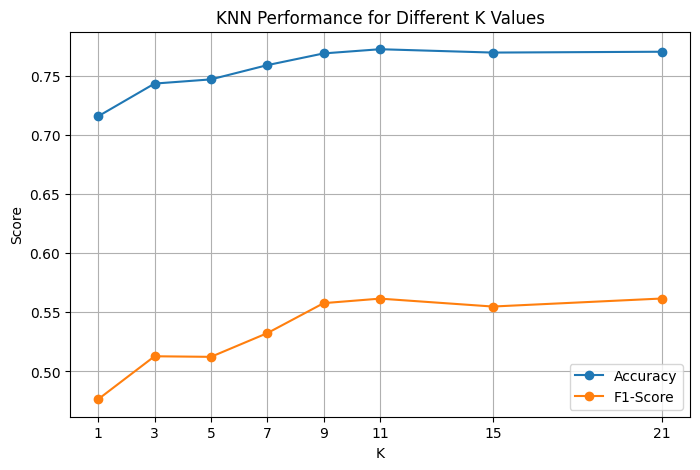

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["K"],
    results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("K")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

I would select a K value that gives a good balance between accuracy and F1-score. I would not simply choose the smallest or largest K because a small K may overfit the data, while a large K can make the model too simple and lead to underfitting.


In [17]:
# Replace 7 with your chosen K
chosen_k = 7

# Train final KNN model
final_knn = KNeighborsClassifier(n_neighbors=chosen_k)

final_knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_final = final_knn.predict(X_test_scaled)

Now calculate the complete metrics:

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, pos_label=1)
recall = recall_score(y_test, y_pred_final, pos_label=1)
f1 = f1_score(y_test, y_pred_final, pos_label=1)

print("Final KNN Results")
print("-----------------")
print("K          :", chosen_k)
print("Accuracy   :", accuracy)
print("Precision  :", precision)
print("Recall     :", recall)
print("F1-Score   :", f1)

Final KNN Results
-----------------
K          : 7
Accuracy   : 0.759403832505323
Precision  : 0.5498575498575499
Recall     : 0.516042780748663
F1-Score   : 0.5324137931034483


Confusion Matrix:
[[877 158]
 [181 193]]


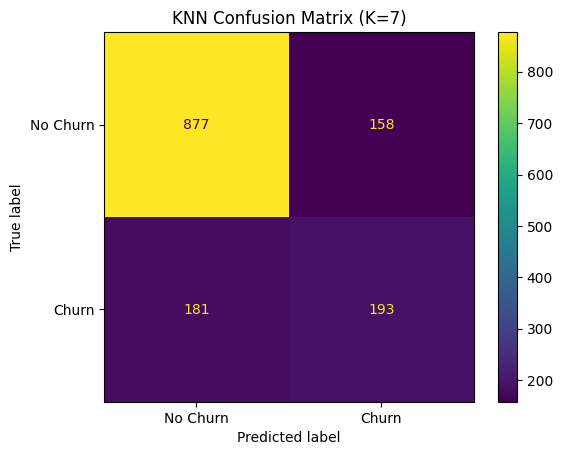

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title(f"KNN Confusion Matrix (K={chosen_k})")
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_test, y_pred_final)
precision_knn = precision_score(y_test, y_pred_final, pos_label=1)
recall_knn = recall_score(y_test, y_pred_final, pos_label=1)
f1_knn = f1_score(y_test, y_pred_final, pos_label=1)

print("KNN Accuracy :", accuracy_knn)
print("KNN Precision:", precision_knn)
print("KNN Recall   :", recall_knn)
print("KNN F1-Score :", f1_knn)

KNN Accuracy : 0.759403832505323
KNN Precision: 0.5498575498575499
KNN Recall   : 0.516042780748663
KNN F1-Score : 0.5324137931034483


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, pos_label=1)
dt_recall = recall_score(y_test, y_pred_dt, pos_label=1)
dt_f1 = f1_score(y_test, y_pred_dt, pos_label=1)

print("Decision Tree")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)

Decision Tree
Accuracy : 0.7260468417317246
Precision: 0.4837837837837838
Recall   : 0.4786096256684492
F1-Score : 0.48118279569892475


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, pos_label=1)
rf_recall = recall_score(y_test, y_pred_rf, pos_label=1)
rf_f1 = f1_score(y_test, y_pred_rf, pos_label=1)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest
Accuracy : 0.7849538679914834
Precision: 0.6179401993355482
Recall   : 0.49732620320855614
F1-Score : 0.5511111111111111


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        accuracy,
        accuracy_knn
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        precision,
        precision_knn
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        recall,
        recall_knn
    ],
    "F1-Score": [
        dt_f1,
        rf_f1,
        f1,
        f1_knn
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.726047   0.483784  0.478610  0.481183
1        Random Forest  0.784954   0.617940  0.497326  0.551111
2  Logistic Regression  0.759404   0.549858  0.516043  0.532414
3                  KNN  0.759404   0.549858  0.516043  0.532414


Since the dataset is imbalanced, accuracy alone is not enough to evaluate the models. Recall is important for churn prediction because it shows how many actual churn customers are correctly detected. Precision and F1-score also help in understanding false predictions and the overall balance of the model
 From the given results, Random Forest has the highest accuracy (78.50%), precision (61.79%), and F1-score (55.12%). Logistic Regression and KNN show the same results, while Decision Tree has the lowest scores.
On the other hand, Logistic Regression and KNN have the highest recall (51.60%), which means they detect more of the actual churn customers in this test set. Therefore, recall and F1-score are important metrics here, especially when the main goal is to identify customers who are likely to churn.


In [29]:
import pandas as pd
import numpy as np

# Get feature names
feature_names = X.columns

# Get logistic regression coefficients
coefficients = logistic_model.coef_[0]

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

# Create table
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

# Add interpretation
def interpret(row):
    if row["Coefficient"] > 0:
        return f"Positive effect: odds of churn increase by about {(row['Odds Ratio'] - 1) * 100:.1f}% for a 1-SD increase."
    else:
        return f"Negative effect: odds of churn decrease by about {(1 - row['Odds Ratio']) * 100:.1f}% for a 1-SD increase."

coef_table["Interpretation"] = coef_table.apply(interpret, axis=1)

# Display
print(coef_table.to_string(index=False))

                              Feature  Coefficient  Odds Ratio                                                               Interpretation
                        SeniorCitizen     0.053073    1.054507   Positive effect: odds of churn increase by about 5.5% for a 1-SD increase.
                               tenure    -1.236528    0.290391  Negative effect: odds of churn decrease by about 71.0% for a 1-SD increase.
                       MonthlyCharges    -0.920153    0.398458  Negative effect: odds of churn decrease by about 60.2% for a 1-SD increase.
                         TotalCharges     0.514285    1.672442  Positive effect: odds of churn increase by about 67.2% for a 1-SD increase.
                          gender_Male     0.011094    1.011156   Positive effect: odds of churn increase by about 1.1% for a 1-SD increase.
                          Partner_Yes     0.010866    1.010926   Positive effect: odds of churn increase by about 1.1% for a 1-SD increase.
                    

Make the table easier to read

In [30]:
coef_table_sorted = coef_table.reindex(
    coef_table["Coefficient"].abs().sort_values(ascending=False).index
)

print(coef_table_sorted.head(10).to_string(index=False))

                    Feature  Coefficient  Odds Ratio                                                               Interpretation
                     tenure    -1.236528    0.290391  Negative effect: odds of churn decrease by about 71.0% for a 1-SD increase.
             MonthlyCharges    -0.920153    0.398458  Negative effect: odds of churn decrease by about 60.2% for a 1-SD increase.
InternetService_Fiber optic     0.776154    2.173099 Positive effect: odds of churn increase by about 117.3% for a 1-SD increase.
          Contract_Two year    -0.586859    0.556071  Negative effect: odds of churn decrease by about 44.4% for a 1-SD increase.
               TotalCharges     0.514285    1.672442  Positive effect: odds of churn increase by about 67.2% for a 1-SD increase.
          Contract_One year    -0.285509    0.751632  Negative effect: odds of churn decrease by about 24.8% for a 1-SD increase.
        StreamingMovies_Yes     0.257227    1.293338  Positive effect: odds of churn incre

Interpret at least 4 features

In [31]:
print(coef_table_sorted.head(10))

                        Feature  Coefficient  Odds Ratio  \
1                        tenure    -1.236528    0.290391   
2                MonthlyCharges    -0.920153    0.398458   
10  InternetService_Fiber optic     0.776154    2.173099   
25            Contract_Two year    -0.586859    0.556071   
3                  TotalCharges     0.514285    1.672442   
24            Contract_One year    -0.285509    0.751632   
23          StreamingMovies_Yes     0.257227    1.293338   
21              StreamingTV_Yes     0.257144    1.293231   
9             MultipleLines_Yes     0.216167    1.241310   
26         PaperlessBilling_Yes     0.182034    1.199655   

                                       Interpretation  
1   Negative effect: odds of churn decrease by abo...  
2   Negative effect: odds of churn decrease by abo...  
10  Positive effect: odds of churn increase by abo...  
25  Negative effect: odds of churn decrease by abo...  
3   Positive effect: odds of churn increase by abo...  
24 

Tenure: The coefficient is -1.235528 and the odds ratio is 0.290391. This means that, keeping other features constant, a one-standard-deviation increase in tenure is linked to about 71% lower odds of churn.

MonthlyCharges: The coefficient is -0.920153 with an odds ratio of 0.398458. With other features unchanged, a one-standard-deviation increase in MonthlyCharges is associated with around 60% lower odds of churn.

InternetService_Fiber optic: The coefficient is 0.776154 and the odds ratio is 2.173099. Compared with the reference Internet Service category, Fiber optic customers have about 2.17 times higher odds of churn.

Contract_Two year:The coefficient is -0.586589 and the odds ratio is 0.556071. Compared with the reference contract category, customers on a two-year contract have around 44% lower odds of churn.


The Logistic Regression coefficients can be compared with the patterns observed in the Lab 2 EDA and the feature importances from the Decision Tree in Lab 3. Features that have large absolute coefficients in Logistic Regression and high Decision Tree importance provide consistent evidence that they are influential for predicting churn, while differences can occur because the two models measure feature influence differently.